In [ ]:
# Length of Hospital Stay Analysis

## 1. Data Loading

In [103]:
import pandas as pd

df = pd.read_csv("../data/hospital_data.csv")

df.head()

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,07-02-2024,12-02-2024,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,11-03-2023,14-03-2023,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,02-01-2025,03-01-2025,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,30-12-2023,06-01-2024,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,10-05-2022,20-05-2022,Mizoram,2022,10,No,Recovered,4,No,25000


In [104]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Condition', 'Medication ',
       'Admission_Date', 'Discharge_Date', 'Patient_State',
       'Year_of_Admission', 'Length_of_Stay', 'Readmission', 'Outcome',
       'Satisfaction', 'Insurance_Claimed', 'Total_Cost'],
      dtype='object')

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984 entries, 0 to 983
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Patient_ID         984 non-null    int64 
 1   Age                984 non-null    int64 
 2   Gender             984 non-null    object
 3   Condition          984 non-null    object
 4   Medication         984 non-null    object
 5   Admission_Date     984 non-null    object
 6   Discharge_Date     984 non-null    object
 7   Patient_State      984 non-null    object
 8   Year_of_Admission  984 non-null    int64 
 9   Length_of_Stay     984 non-null    int64 
 10  Readmission        984 non-null    object
 11  Outcome            984 non-null    object
 12  Satisfaction       984 non-null    int64 
 13  Insurance_Claimed  984 non-null    object
 14  Total_Cost         984 non-null    int64 
dtypes: int64(6), object(9)
memory usage: 115.4+ KB


In [106]:
df.head()

,Patient_ID,Age,Gender,Condition,Medication,Admission_Date,Discharge_Date,Patient_State,Year_of_Admission,Length_of_Stay,Readmission,Outcome,Satisfaction,Insurance_Claimed,Total_Cost
0,1,45,Female,Heart Disease,Angioplasty,07-02-2024,12-02-2024,Kerala,2024,5,No,Recovered,4,Yes,15000
1,2,60,Male,Diabetes,Insulin Therapy,11-03-2023,14-03-2023,Goa,2023,3,Yes,Stable,3,No,2000
2,3,32,Female,Fractured Arm,X-Ray and Splint,02-01-2025,03-01-2025,Maharastra,2025,1,No,Recovered,5,Yes,500
3,4,75,Male,Stroke,CT Scan and Medication,30-12-2023,06-01-2024,Manipur,2023,7,Yes,Stable,2,No,10000
4,5,50,Female,Cancer,Surgery and Chemotherapy,10-05-2022,20-05-2022,Mizoram,2022,10,No,Recovered,4,No,25000


In [107]:
# Missing values check
df.isnull().sum()

Patient_ID           0
Age                  0
Gender               0
Condition            0
Medication           0
Admission_Date       0
Discharge_Date       0
Patient_State        0
Year_of_Admission    0
Length_of_Stay       0
Readmission          0
Outcome              0
Satisfaction         0
Insurance_Claimed    0
Total_Cost           0
dtype: int64

In [108]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [109]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'], dayfirst=True)
df['Discharge_Date'] = pd.to_datetime(df['Discharge_Date'], dayfirst=True)

In [110]:
df.dtypes

Patient_ID                    int64
Age                           int64
Gender                       object
Condition                    object
Medication                   object
Admission_Date       datetime64[ns]
Discharge_Date       datetime64[ns]
Patient_State                object
Year_of_Admission             int64
Length_of_Stay                int64
Readmission                  object
Outcome                      object
Satisfaction                  int64
Insurance_Claimed            object
Total_Cost                    int64
dtype: object

In [111]:
df['calculated_stay'] = (df['Discharge_Date'] - df['Admission_Date']).dt.days

df[['Length_of_Stay', 'calculated_stay']].head(10)

,Length_of_Stay,calculated_stay
0,5,5
1,3,3
2,1,1
3,7,7
4,10,10
5,2,2
6,4,4
7,6,6
8,8,8
9,1,1


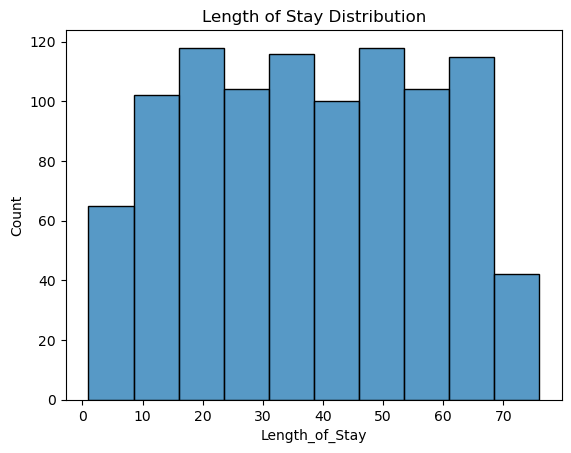

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Length_of_Stay'], bins=10)
plt.title("Length of Stay Distribution")
plt.show()

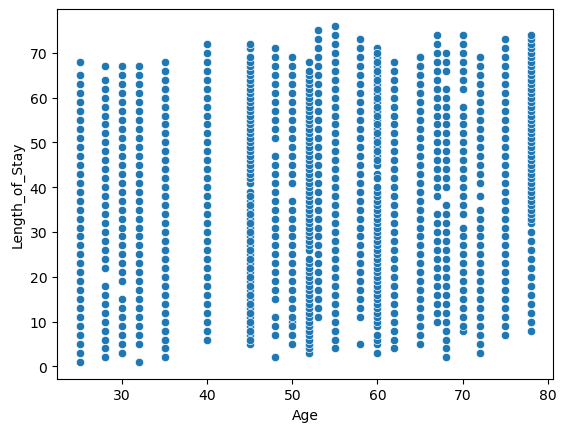

In [113]:
sns.scatterplot(x='Age', y='Length_of_Stay', data=df)
plt.show()

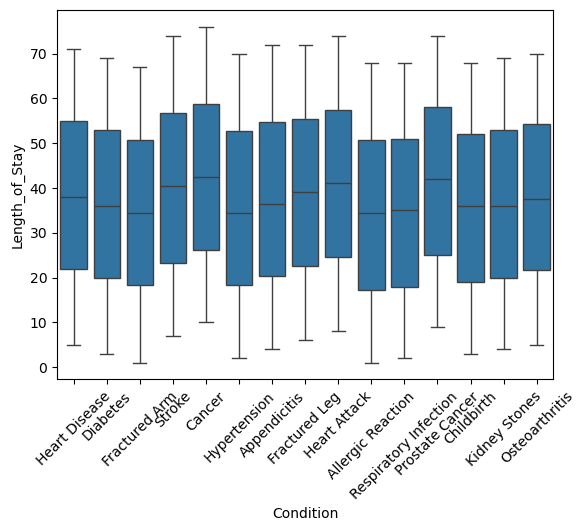

In [114]:
sns.boxplot(x='Condition', y='Length_of_Stay', data=df)
plt.xticks(rotation=45)
plt.show()

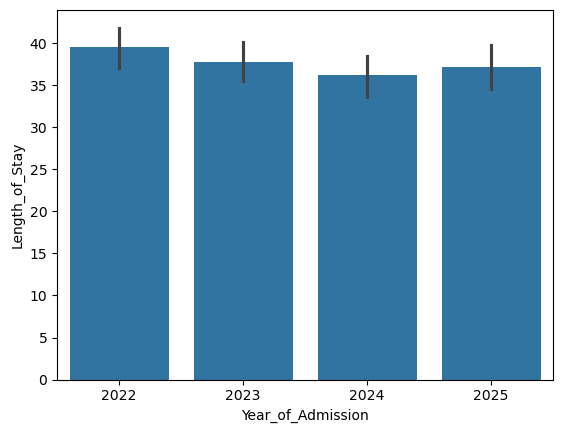

In [115]:
sns.barplot(x='Year_of_Admission', y='Length_of_Stay', data=df)
plt.show()

In [116]:

df['admission_month'] = df['Admission_Date'].dt.month
df['admission_day'] = df['Admission_Date'].dt.day

In [117]:
df_encoded = df_encoded.drop([
    'Patient_ID',
    'Admission_Date',
    'Discharge_Date',
    'Year_of_Admission',
    'admission_day',
    'admission_month'
], axis=1, errors='ignore')

In [118]:
print(df_encoded.columns)

Index(['Age', 'Length_of_Stay', 'Satisfaction', 'Gender_Male',
       'Condition_Appendicitis', 'Condition_Cancer', 'Condition_Childbirth',
       'Condition_Diabetes', 'Condition_Heart', 'Condition_Hypertension',
       'Condition_Injury', 'Condition_Kidney Stones',
       'Condition_Osteoarthritis', 'Condition_Prostate Cancer',
       'Condition_Respiratory Infection', 'Condition_Stroke',
       'Medication _Antibiotics and Rest', 'Medication _Appendectomy',
       'Medication _CT Scan and Medication',
       'Medication _Cardiac Catheterization',
       'Medication _Cast and Physical Therapy',
       'Medication _Delivery and Postnatal Care',
       'Medication _Epinephrine Injection', 'Medication _Insulin Therapy',
       'Medication _Lithotripsy', 'Medication _Medication and Counseling',
       'Medication _Physical Therapy and Pain Management',
       'Medication _Radiation Therapy', 'Medication _Surgery and Chemotherapy',
       'Medication _X-Ray and Splint', 'Patient_State_Aru

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = df_encoded.drop('Length_of_Stay', axis=1)
y = df_encoded['Length_of_Stay']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2: -0.34525319940729315
MAE: 19.889110942452653


In [120]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R2: -0.06204344950251883
MAE: 17.745635738793347


Age                                0.205742
Insurance_Claimed_Yes              0.093598
Patient_State_Delhi                0.046254
Patient_State_Karnataka            0.042992
Satisfaction                       0.040341
Patient_State_Assam                0.037189
Patient_State_Arunachal Pradesh    0.035580
Patient_State_Kerala               0.033322
Patient_State_Meghalaya            0.026836
Patient_State_Punjab               0.025358
dtype: float64


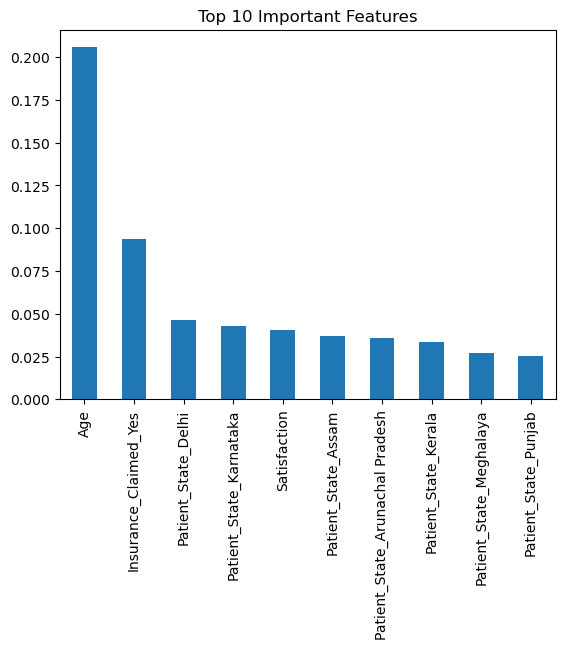

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()